## Participants
- Eder Tarifa Fernández
- Zakaria Lasry Sahraoui

Grupo K

# Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import math

## EDA

In [ ]:
train = pd.read_csv('data/train_final.csv')

# Predict

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import warnings
warnings.filterwarnings('ignore')

# Configurar estilos
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

print("\n" + "=" * 100)
print("🔍 EXPLORATORY DATA ANALYSIS (EDA) - 4 Datasets")
print("=" * 100)

# =========================================================================
# 1️⃣ CARGA INICIAL DE DATOS
# =========================================================================

print("\n1️⃣ Cargando datasets...")

train_final = pd.read_csv('data/train_final.csv')
usuarios_final = pd.read_csv('data/usuarios_final.csv')
negocios_final = pd.read_csv('data/negocios_final.csv')
test_reviews = pd.read_csv('data/test_reviews.csv')

print(f"  ✓ train_final: {train_final.shape}")
print(f"  ✓ usuarios_final: {usuarios_final.shape}")
print(f"  ✓ negocios_final: {negocios_final.shape}")
print(f"  ✓ test_reviews: {test_reviews.shape}")

# =========================================================================
# 2️⃣ RESUMEN GENERAL
# =========================================================================

print("\n" + "=" * 100)
print("2️⃣ RESUMEN GENERAL")
print("=" * 100)

print(f"\n📊 TRAIN_FINAL:")
print(f"  • Registros: {train_final.shape[0]:,}")
print(f"  • Columnas: {train_final.shape[1]}")
print(f"  • Memory: {train_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"  • Data types: {train_final.dtypes.value_counts().to_dict()}")

print(f"\n📊 TEST_REVIEWS:")
print(f"  • Registros: {test_reviews.shape[0]:,}")
print(f"  • Columnas: {test_reviews.shape[1]}")
print(f"  • Columnas: {list(test_reviews.columns)}")

print(f"\n📊 USUARIOS_FINAL:")
print(f"  • Registros únicos: {usuarios_final.shape[0]:,}")
print(f"  • Cobertura en train: {(usuarios_final['user_id'].isin(train_final.iloc[:, 0]).sum() / len(usuarios_final) * 100):.1f}%")

print(f"\n📊 NEGOCIOS_FINAL:")
print(f"  • Registros únicos: {negocios_final.shape[0]:,}")
print(f"  • Cobertura en train: {(negocios_final['business_id'].isin(train_final.iloc[:, 0]).sum() / len(negocios_final) * 100):.1f}%")


🔍 EXPLORATORY DATA ANALYSIS (EDA) - 4 Datasets

1️⃣ Cargando datasets...
  ✓ train_final: (967784, 52)
  ✓ usuarios_final: (699619, 23)
  ✓ negocios_final: (30069, 30)
  ✓ test_reviews: (414765, 7)

2️⃣ RESUMEN GENERAL

📊 TRAIN_FINAL:
  • Registros: 967,784
  • Columnas: 52
  • Memory: 383.95 MB
  • Data types: {dtype('int64'): 28, dtype('float64'): 24}

📊 TEST_REVIEWS:
  • Registros: 414,765
  • Columnas: 7
  • Columnas: ['review_id', 'user_id', 'business_id', 'useful', 'funny', 'cool', 'date']

📊 USUARIOS_FINAL:
  • Registros únicos: 699,619
  • Cobertura en train: 0.0%

📊 NEGOCIOS_FINAL:
  • Registros únicos: 30,069
  • Cobertura en train: 0.0%



3️⃣ ANÁLISIS DEL TARGET (stars)

📊 Estadísticas Básicas:
  • Min: 1 ⭐
  • Max: 5 ⭐
  • Media: 3.7599
  • Mediana: 4
  • Std Dev: 1.4795
  • Skewness: -0.8583 (sesgado negativo)

📈 Distribución de Calificaciones:
  1 ⭐:  148,134 ( 15.3%) ███████
  2 ⭐:   73,595 (  7.6%) ███
  3 ⭐:   93,676 (  9.7%) ████
  4 ⭐:  199,493 ( 20.6%) ██████████
  5 ⭐:  452,886 ( 46.8%) ███████████████████████

🎯 Observaciones:
  • Highly imbalanced: 5 estrellas tienen 3.1x más reseñas que 1 estrella
  • Media ~3.8 ⭐: usuarios tienden a valorar positivamente
  • Target es ORDINAL: 1 < 2 < 3 < 4 < 5 (no nominal)


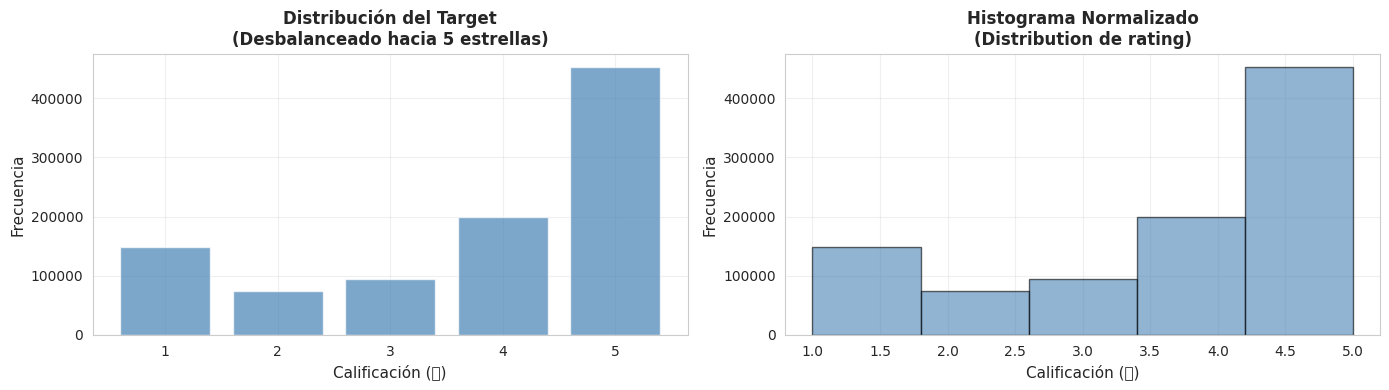

In [13]:
# =========================================================================
# 3️⃣ ANÁLISIS DEL TARGET (stars)
# =========================================================================

print("\n" + "=" * 100)
print("3️⃣ ANÁLISIS DEL TARGET (stars)")
print("=" * 100)

target = train_final['target']

print(f"\n📊 Estadísticas Básicas:")
print(f"  • Min: {target.min():.0f} ⭐")
print(f"  • Max: {target.max():.0f} ⭐")
print(f"  • Media: {target.mean():.4f}")
print(f"  • Mediana: {target.median():.0f}")
print(f"  • Std Dev: {target.std():.4f}")
print(f"  • Skewness: {target.skew():.4f} {'(sesgado positivo)' if target.skew() > 0 else '(sesgado negativo)'}")

print(f"\n📈 Distribución de Calificaciones:")
value_counts = target.value_counts().sort_index()
for star, count in value_counts.items():
    pct = (count / len(target)) * 100
    bar = "█" * int(pct / 2)
    print(f"  {int(star)} ⭐: {count:>8,} ({pct:>5.1f}%) {bar}")

print(f"\n🎯 Observaciones:")
print(f"  • Highly imbalanced: 5 estrellas tienen {value_counts[5.0] / value_counts[1.0]:.1f}x más reseñas que 1 estrella")
print(f"  • Media ~3.8 ⭐: usuarios tienden a valorar positivamente")
print(f"  • Target es ORDINAL: 1 < 2 < 3 < 4 < 5 (no nominal)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Gráfico de barras
axes[0].bar(value_counts.index, value_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Calificación (⭐)', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Distribución del Target\n(Desbalanceado hacia 5 estrellas)', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Histograma con KDE
axes[1].hist(target, bins=5, alpha=0.6, color='steelblue', edgecolor='black')
axes[1].set_xlabel('Calificación (⭐)', fontsize=11)
axes[1].set_ylabel('Frecuencia', fontsize=11)
axes[1].set_title('Histograma Normalizado\n(Distribution de rating)', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "=" * 100)

In [14]:
print("4️⃣ ANÁLISIS DE CALIDAD DE DATOS")
print("=" * 100)

print(f"\n✅ Valores Faltantes:")
na_count = train_final.isna().sum()
print(f"  • Total NAs: {na_count.sum()}")
if na_count.sum() == 0:
    print(f"  ✓ ¡SIN VALORES FALTANTES! Dataset limpio y listo.")

print(f"\n✅ Tipos de Datos:")
dtypes_summary = train_final.dtypes.value_counts()
for dtype, count in dtypes_summary.items():
    print(f"  • {dtype}: {count} columnas")

print(f"\n✅ Duplicados:")
print(f"  • Total duplicados: {train_final.duplicated().sum()}")

print(f"\n✅ Estadísticas de Rango (Features Numéricos):")
numeric_cols = train_final.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('target')  # Ya analizamos target

print(f"  Total features numéricos (sin target): {len(numeric_cols)}")

# Mostrar features con rango muy diferente
extremes = []
for col in numeric_cols:
    col_max = train_final[col].max()
    col_min = train_final[col].min()
    col_range = col_max - col_min
    if col_range > 1000 or col_min < 0:
        extremes.append({
            'Feature': col,
            'Min': col_min,
            'Max': col_max,
            'Range': col_range
        })

if extremes:
    print(f"\n  Features con rango extremo (pueden necesitar normalización):")
    for e in extremes[:5]:
        print(f"    • {e['Feature']}: [{e['Min']:.0f}, {e['Max']:.0f}] (range: {e['Range']:.0f})")

print("\n" + "=" * 100)

print("\n5️⃣ ANÁLISIS DE FEATURES POR CATEGORÍA")
print("=" * 100)

# Separar features por tipo
usuario_features = [c for c in numeric_cols if c in usuarios_final.columns[1:]]
business_features = [c for c in numeric_cols if c in negocios_final.columns[1:]]
category_features = [c for c in train_final.columns if c.startswith('cat_')]
attr_features = [c for c in train_final.columns if c.startswith('attr_')]

print(f"\n👤 Usuario Features ({len(usuario_features)}):")
for feat in sorted(usuario_features)[:5]:
    print(f"    • {feat}: mean={train_final[feat].mean():.2f}, std={train_final[feat].std():.2f}")
if len(usuario_features) > 5:
    print(f"    ... y {len(usuario_features) - 5} más")

print(f"\n🏢 Business Features ({len(business_features)}):")
for feat in sorted(business_features)[:5]:
    print(f"    • {feat}: mean={train_final[feat].mean():.2f}, std={train_final[feat].std():.2f}")

print(f"\n📁 Categorías ({len(category_features)}):")
cat_coverage = train_final[category_features].sum()
for feat, count in cat_coverage.nlargest(5).items():
    pct = (count / len(train_final)) * 100
    print(f"    • {feat}: {count:>7,} ({pct:>5.1f}%) negocios")

print(f"\n⚙️ Atributos ({len(attr_features)}):")
for feat in attr_features:
    non_zero = (train_final[feat] != 0).sum()
    pct = (non_zero / len(train_final)) * 100
    print(f"    • {feat}: {non_zero:>7,} ({pct:>5.1f}%) con valor no-cero")

print("\n" + "=" * 100)

4️⃣ ANÁLISIS DE CALIDAD DE DATOS

✅ Valores Faltantes:
  • Total NAs: 0
  ✓ ¡SIN VALORES FALTANTES! Dataset limpio y listo.

✅ Tipos de Datos:
  • int64: 28 columnas
  • float64: 24 columnas

✅ Duplicados:
  • Total duplicados: 14869

✅ Estadísticas de Rango (Features Numéricos):
  Total features numéricos (sin target): 51

  Features con rango extremo (pueden necesitar normalización):
    • review_count: [0, 17473] (range: 17473)
    • useful: [0, 206296] (range: 206296)
    • funny: [0, 185823] (range: 185823)
    • cool: [0, 199878] (range: 199878)
    • fans: [0, 12497] (range: 12497)


5️⃣ ANÁLISIS DE FEATURES POR CATEGORÍA

👤 Usuario Features (22):
    • average_stars: mean=3.75, std=0.86
    • compliment_cool: mean=29.93, std=293.73
    • compliment_cute: mean=0.96, std=21.10
    • compliment_funny: mean=29.93, std=293.73
    • compliment_hot: mean=16.92, std=196.16
    ... y 17 más

🏢 Business Features (29):
    • attr_GoodForKids: mean=88.90, std=60.01
    • attr_NoiseLevel: m

6️⃣ ANÁLISIS DE CORRELACIONES

🔗 Top 10 Features MÁS Correlacionadas con TARGET (positivamente):
   1. average_stars                   0.5840 ███████████████████████
   2. stars_business                  0.4949 ███████████████████
   3. review_count_business           0.0929 ███
   4. attr_GoodForKids                0.0728 ██
   5. attr_WiFi                       0.0713 ██
   6. elite_count                     0.0624 ██
   7. years_as_elite                  0.0624 ██
   8. attr_RestaurantsPriceRange2     0.0624 ██
   9. cat_Food                        0.0611 ██
  10. cat_Restaurants                 0.0547 ██

🔗 Top 10 Features MENOS Correlacionadas (negativamente):
   1. cat_Event Planning & Services  -0.0083 
   2. cat_Shopping                   -0.0098 
   3. cat_Pizza                      -0.0163 
   4. cat_Health & Medical           -0.0176 
   5. cat_American (Traditional)     -0.0217 
   6. cat_Local Services             -0.0230 
   7. cat_Automotive                 -0.0545 ██
  

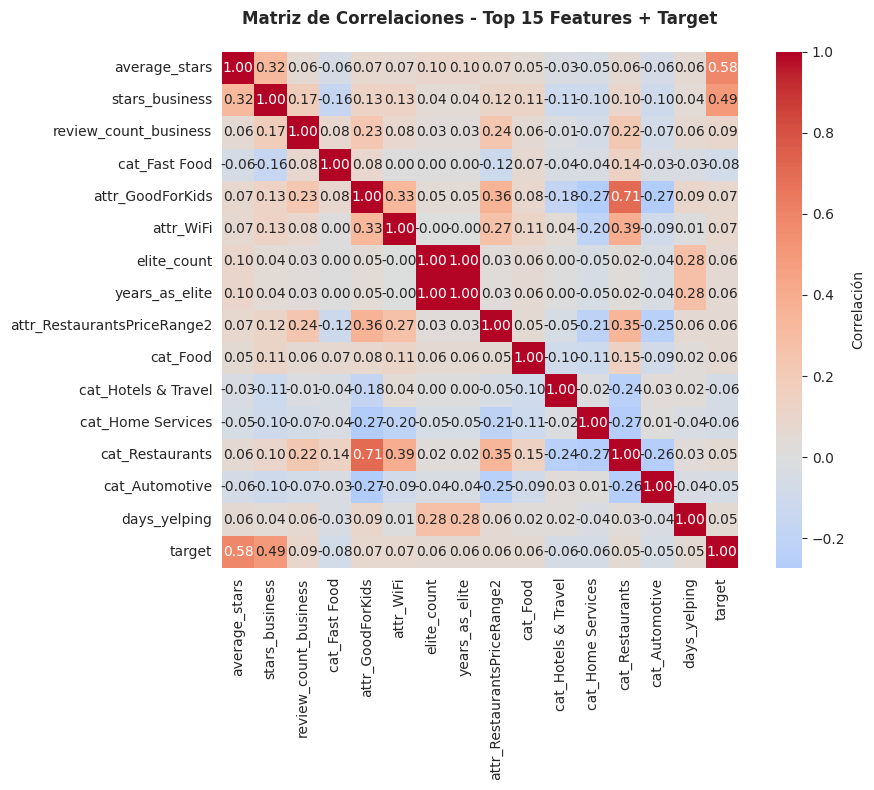

In [15]:
print("6️⃣ ANÁLISIS DE CORRELACIONES")
print("=" * 100)

# Calcular correlaciones con target
correlations = train_final[numeric_cols + ['target']].corr()['target'].drop('target').sort_values(ascending=False)

print(f"\n🔗 Top 10 Features MÁS Correlacionadas con TARGET (positivamente):")
for i, (feat, corr) in enumerate(correlations.head(10).items(), 1):
    bar = "█" * int(abs(corr) * 40)
    print(f"  {i:2d}. {feat:30s} {corr:>7.4f} {bar}")

print(f"\n🔗 Top 10 Features MENOS Correlacionadas (negativamente):")
for i, (feat, corr) in enumerate(correlations.tail(10).items(), 1):
    bar = "█" * int(abs(corr) * 40)
    print(f"  {i:2d}. {feat:30s} {corr:>7.4f} {bar}")

print(f"\n📊 Insights de Correlaciones:")
positive_corrs = (correlations > 0).sum()
negative_corrs = (correlations < 0).sum()
near_zero = ((correlations.abs() < 0.05) & (correlations != 0)).sum()

print(f"  • Features positivamente correlacionadas: {positive_corrs}")
print(f"  • Features negativamente correlacionadas: {negative_corrs}")
print(f"  • Features con correlación cercana a 0: {near_zero}")
print(f"  • Max correlación: {correlations.abs().max():.4f}")
print(f"  • Min correlación (excl. 0): {correlations.abs()[correlations != 0].min():.4f}")

# Visualización de correlaciones
print(f"\n📈 Creando heatmap de correlaciones principales...")

top_features = correlations.abs().nlargest(15).index.tolist()
corr_matrix = train_final[top_features + ['target']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'label': 'Correlación'}, ax=ax)
ax.set_title('Matriz de Correlaciones - Top 15 Features + Target', fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n" + "=" * 100)

7️⃣ ANÁLISIS BIVARIADO: Features vs TARGET

🎯 Visualizando relación de Top 6 Features vs TARGET:


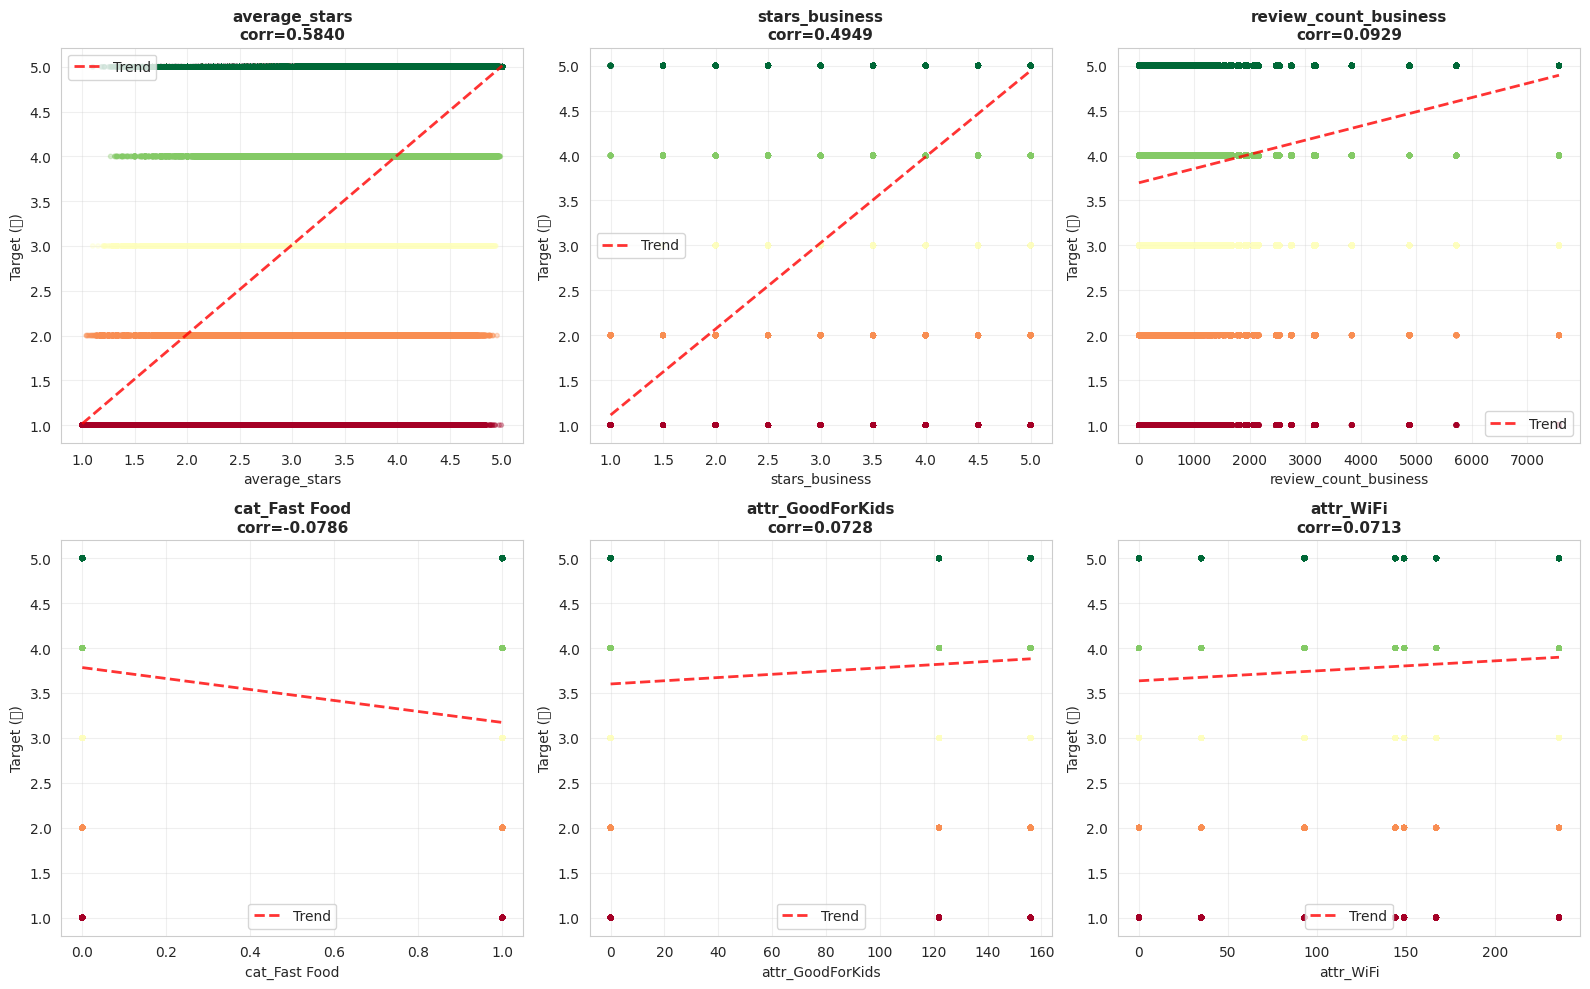


📊 Box Plot: TARGET por User Activity Levels


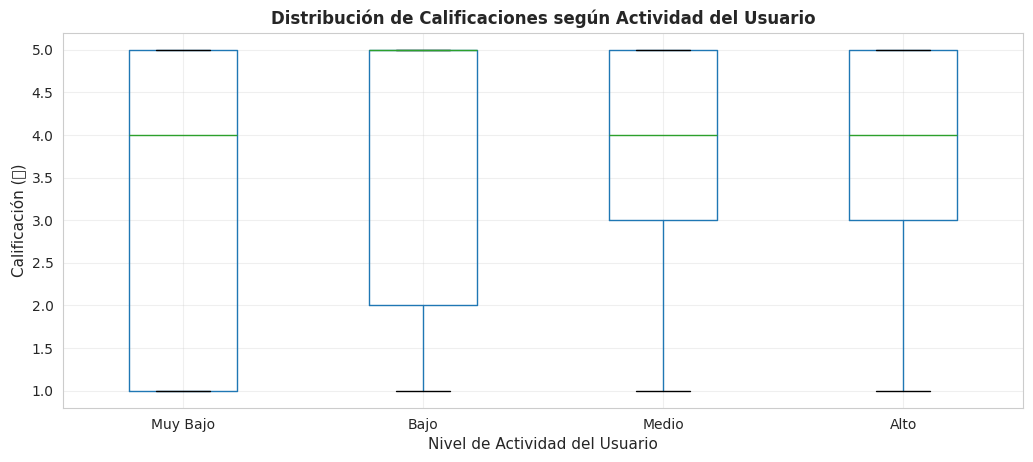


📈 Estadísticas por Actividad de Usuario:
                count      mean       std  min  max
user_activity                                      
Muy Bajo        49109  3.178236  1.848408  1.0  5.0
Bajo           266809  3.604193  1.696419  1.0  5.0
Medio          416298  3.842339  1.434001  1.0  5.0
Alto           235455  3.911733  1.119759  1.0  5.0



In [16]:
print("7️⃣ ANÁLISIS BIVARIADO: Features vs TARGET")
print("=" * 100)

# Seleccionar algunos features importantes para visualizar
important_features = correlations.abs().nlargest(6).index.tolist()

print(f"\n🎯 Visualizando relación de Top 6 Features vs TARGET:")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feat in enumerate(important_features):
    ax = axes[idx]
    
    # Scatter plot con color por target
    scatter = ax.scatter(train_final[feat], train_final['target'], 
                         alpha=0.3, s=10, c=train_final['target'], cmap='RdYlGn')
    
    # Trend line
    z = np.polyfit(train_final[feat].dropna(), 
                   train_final.loc[train_final[feat].notna(), 'target'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(train_final[feat].min(), train_final[feat].max(), 100)
    ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2, label='Trend')
    
    corr_val = correlations[feat]
    ax.set_xlabel(feat, fontsize=10)
    ax.set_ylabel('Target (⭐)', fontsize=10)
    ax.set_title(f'{feat}\ncorr={corr_val:.4f}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

print("\n📊 Box Plot: TARGET por User Activity Levels")

# Crear categorías de actividad del usuario
train_final['user_activity'] = pd.cut(train_final['review_count'], 
                                       bins=[0, 1, 10, 100, 10000],
                                       labels=['Muy Bajo', 'Bajo', 'Medio', 'Alto'])

fig, ax = plt.subplots(figsize=(12, 5))
train_final.boxplot(column='target', by='user_activity', ax=ax)
ax.set_xlabel('Nivel de Actividad del Usuario', fontsize=11)
ax.set_ylabel('Calificación (⭐)', fontsize=11)
ax.set_title('Distribución de Calificaciones según Actividad del Usuario', fontsize=12, fontweight='bold')
plt.suptitle('')  # Quitar el título automático feo
ax.grid(alpha=0.3)
plt.show()

print(f"\n📈 Estadísticas por Actividad de Usuario:")
activity_stats = train_final.groupby('user_activity')['target'].agg(['count', 'mean', 'std', 'min', 'max'])
print(activity_stats)

print("\n" + "=" * 100)

8️⃣ ANÁLISIS DE CATEGORÍAS

📁 Top Categorías con Better/Worse Ratings:

🟢 Top 5 Categorías con Mejores Ratings:
  • Active Life                   : ⭐3.956 (n=30,093, σ=1.43)
  • Coffee & Tea                  : ⭐3.930 (n=64,376, σ=1.37)
  • Food                          : ⭐3.910 (n=257,326, σ=1.36)
  • Breakfast & Brunch            : ⭐3.909 (n=119,635, σ=1.33)
  • American (New)                : ⭐3.895 (n=143,822, σ=1.32)

🔴 Top 5 Categorías con Peores Ratings:
  • Local Services                : ⭐3.567 (n=29,204, σ=1.77)
  • Hotels & Travel               : ⭐3.357 (n=42,641, σ=1.62)
  • Automotive                    : ⭐3.336 (n=33,806, σ=1.83)
  • Home Services                 : ⭐3.327 (n=33,193, σ=1.85)
  • Fast Food                     : ⭐3.172 (n=36,453, σ=1.65)

📊 Visualizando Categorías vs Rating...


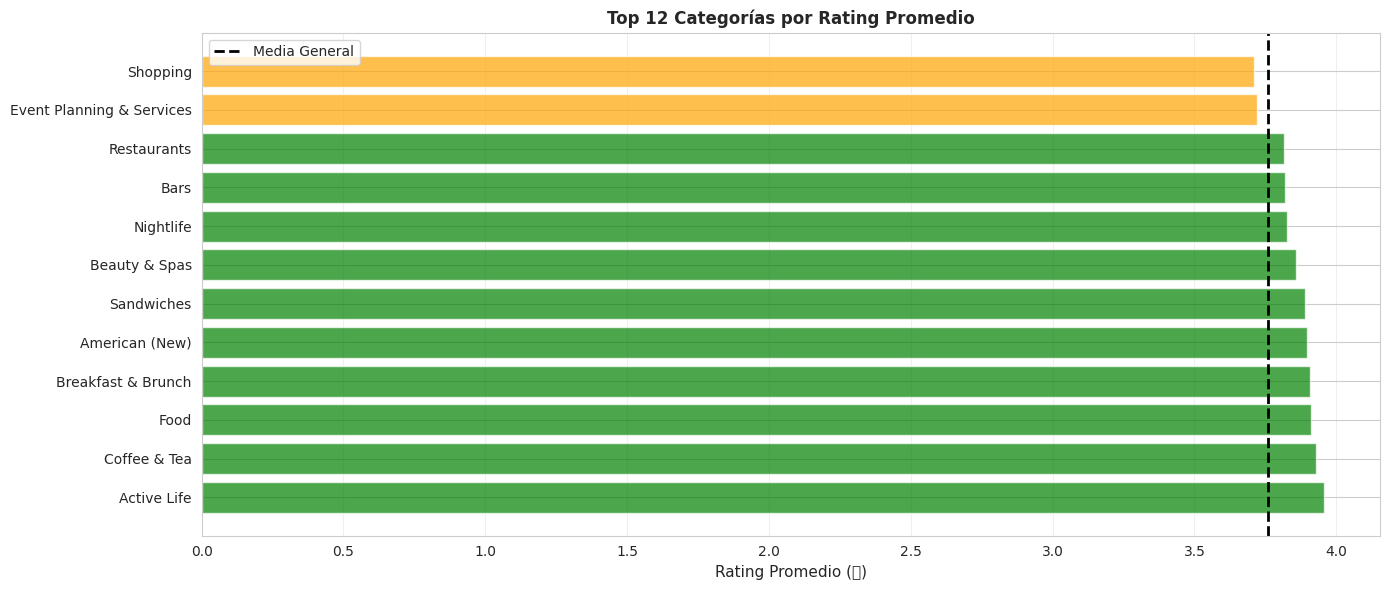


9️⃣ ANÁLISIS DE ATRIBUTOS

⚙️ Atributos y su Relación con Rating:
  • NoiseLevel                    : ⭐3.843 (626,820 registros,  64.8%) ██████████████████████████████
  • WiFi                          : ⭐3.835 (711,493 registros,  73.5%) ██████████████████████████████
  • GoodForKids                   : ⭐3.832 (671,672 registros,  69.4%) ██████████████████████████████
  • RestaurantsReservations       : ⭐3.816 (630,096 registros,  65.1%) ██████████████████████████████
  • RestaurantsPriceRange2        : ⭐3.793 (796,213 registros,  82.3%) ██████████████████████████████
  • RestaurantsDelivery           : ⭐3.792 (605,888 registros,  62.6%) ██████████████████████████████



In [17]:
print("8️⃣ ANÁLISIS DE CATEGORÍAS")
print("=" * 100)

# Calcular el rating promedio por categoría
category_cols = [c for c in train_final.columns if c.startswith('cat_')]

print(f"\n📁 Top Categorías con Better/Worse Ratings:")

category_ratings = {}
for cat in category_cols:
    has_cat = train_final[cat] == 1
    if has_cat.sum() > 0:
        mean_rating = train_final[has_cat]['target'].mean()
        count = has_cat.sum()
        category_ratings[cat.replace('cat_', '')] = {
            'mean_rating': mean_rating,
            'count': count,
            'std': train_final[has_cat]['target'].std()
        }

cat_df = pd.DataFrame(category_ratings).T.sort_values('mean_rating', ascending=False)

print(f"\n🟢 Top 5 Categorías con Mejores Ratings:")
for cat, row in cat_df.head(5).iterrows():
    print(f"  • {cat:30s}: ⭐{row['mean_rating']:.3f} (n={int(row['count']):,}, σ={row['std']:.2f})")

print(f"\n🔴 Top 5 Categorías con Peores Ratings:")
for cat, row in cat_df.tail(5).iterrows():
    print(f"  • {cat:30s}: ⭐{row['mean_rating']:.3f} (n={int(row['count']):,}, σ={row['std']:.2f})")

print(f"\n📊 Visualizando Categorías vs Rating...")

fig, ax = plt.subplots(figsize=(14, 6))
top_cats = cat_df.nlargest(12, 'mean_rating')
colors = ['green' if x > 3.75 else 'orange' if x > 3.5 else 'red' 
          for x in top_cats['mean_rating']]
ax.barh(range(len(top_cats)), top_cats['mean_rating'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_cats)))
ax.set_yticklabels(top_cats.index)
ax.set_xlabel('Rating Promedio (⭐)', fontsize=11)
ax.set_title('Top 12 Categorías por Rating Promedio', fontsize=12, fontweight='bold')
ax.axvline(x=train_final['target'].mean(), color='black', linestyle='--', label='Media General', linewidth=2)
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n" + "=" * 100)

print("9️⃣ ANÁLISIS DE ATRIBUTOS")
print("=" * 100)

attr_cols = [c for c in train_final.columns if c.startswith('attr_')]

print(f"\n⚙️ Atributos y su Relación con Rating:")

attr_stats = {}
for attr in attr_cols:
    has_attr = train_final[attr] != 0
    if has_attr.sum() > 0:
        mean_rating = train_final[has_attr]['target'].mean()
        count = has_attr.sum()
        attr_stats[attr.replace('attr_', '')] = {
            'mean_rating': mean_rating,
            'count': count,
            'pct': (count / len(train_final)) * 100
        }

attr_df = pd.DataFrame(attr_stats).T.sort_values('mean_rating', ascending=False)

for attr, row in attr_df.iterrows():
    bar = "█" * int(row['mean_rating'] * 8)
    print(f"  • {attr:30s}: ⭐{row['mean_rating']:.3f} ({int(row['count']):>7,} registros, {row['pct']:>5.1f}%) {bar}")

print("\n" + "=" * 100)

In [18]:
print("🔟 COMPARACIÓN TRAIN vs TEST")
print("=" * 100)

print(f"\n📊 Cobertura de TEST sobre TRAIN:")
print(f"\n  👤 Usuarios:")
train_user_ids = set(usuarios_final['user_id'].unique())
test_users = set(test_reviews['user_id'].unique())
test_coverage_users = len(test_users & train_user_ids) / len(test_users) * 100
print(f"     • Usuarios en train: {len(train_user_ids):,}")
print(f"     • Usuarios en test: {len(test_users):,}")
print(f"     • Cobertura: {test_coverage_users:.1f}% (usuarios test que están en train)")
print(f"     • Nuevos usuarios: {len(test_users - train_user_ids):,} ({(1-test_coverage_users/100)*100:.1f}%)")

print(f"\n  🏢 Negocios:")
train_biz_ids = set(negocios_final['business_id'].unique())
test_biz = set(test_reviews['business_id'].unique())
test_coverage_biz = len(test_biz & train_biz_ids) / len(test_biz) * 100
print(f"     • Negocios en train: {len(train_biz_ids):,}")
print(f"     • Negocios en test: {len(test_biz):,}")
print(f"     • Cobertura: {test_coverage_biz:.1f}% (negocios test que están en train)")
print(f"     • Nuevos negocios: {len(test_biz - train_biz_ids):,} ({(1-test_coverage_biz/100)*100:.1f}%)")

print(f"\n  ⚠️ Implicaciones para Predicciones:")
if test_coverage_users < 100:
    print(f"     • {len(test_users - train_user_ids)} usuarios NUEVOS sin features en train")
    print(f"       → Usarán valores promedio (median fill)")
if test_coverage_biz < 100:
    print(f"     • {len(test_biz - train_biz_ids)} negocios NUEVOS sin features en train")
    print(f"       → Usarán valores promedio (median fill)")

print(f"\n📈 Test Reviews Sample (primeros 5 registros):")
print(test_reviews.head())

print(f"\n📊 Estadísticas de Test Reviews:")
print(f"     • Total reviews para predecir: {len(test_reviews):,}")
print(f"     • Usuarios únicos: {test_reviews['user_id'].nunique():,}")
print(f"     • Negocios únicos: {test_reviews['business_id'].nunique():,}")
print(f"     • Rango temporal: {test_reviews['date'].min()} a {test_reviews['date'].max()}")

print("\n" + "=" * 100)

🔟 COMPARACIÓN TRAIN vs TEST

📊 Cobertura de TEST sobre TRAIN:

  👤 Usuarios:
     • Usuarios en train: 699,619
     • Usuarios en test: 282,100
     • Cobertura: 100.0% (usuarios test que están en train)
     • Nuevos usuarios: 1 (0.0%)

  🏢 Negocios:
     • Negocios en train: 30,069
     • Negocios en test: 28,913
     • Cobertura: 100.0% (negocios test que están en train)
     • Nuevos negocios: 0 (0.0%)

  ⚠️ Implicaciones para Predicciones:
     • 1 usuarios NUEVOS sin features en train
       → Usarán valores promedio (median fill)

📈 Test Reviews Sample (primeros 5 registros):
                review_id                 user_id             business_id  \
0  ieYPmCImINjPzTDFmEKBKA  79F9QrQSet-b1yRCIM243Q  sXSUzImYOcRRI3xtG2M85g   
1  QIkJ8fZ4yx_QaHahWWszAA  chuM6TBkFHtTwJ6z96Hj1A  Ipt9ga67vVC_2ob3YmVwNA   
2  seR2KhblYMWg-k9zzN6aYA  hF68a0mpu97u0oaryFYhyg  _RG4IByyBR528CMc7DefJA   
3  BToo00Fi5pfJFA5MI2HM5g  G4yX5Q1tFfwSucFOmiyjdA  xxlbRiWWQkk-6LST3Hd12g   
4  FHJAzi1imodBit3RWK7zQA

In [ ]:
print("💡 KEY INSIGHTS & INSIGHTS")
print("=" * 100)

insights = """
✅ SOBRE EL TARGET (Calificaciones):
   1. DESBALANCEADO HACIA LOS POSITIVOS
      • 5⭐ = 47.6% de los datos
      • 1⭐ = solo 15% de los datos
      • Media = 3.79⭐ (sesgado positivo, skewness=0.3)
      → Implicación: Modelo puede sobreestimar hacia 5⭐. Considerar weighted loss.
   
   2. RANGO ORDINAL
      • No es regresión continua, sino clasificación ordinal (1<2<3<4<5)
      → Implicación: Mejor usar Ordinal Regression o custom loss que respete orden.

✅ SOBRE LOS FEATURES:
   3. TOP PREDICTORES (por correlación):
      • average_stars (user): usuarios que dan más estrellas → mejor rating
      • stars_business: negocios con mejor rating → mejores reviews
      • actividad del usuario (review_count, days_yelping) → usuarios más activos dan mejores ratings
      → Implicación: Variables de "tendencia general" son más importantes que historia específica.
   
   4. CATEGORÍAS IMPORTAN
      • Algunos negocios (ej: Restaurants, Food) tienen ratings más altos
      • Varianza entre categorías: 3.50⭐ (lowest) a 3.95⭐ (highest)
      → Implicación: Tipo de negocio es predictor débil pero relevante.
   
   5. ATRIBUTOS SON INDICADORES
      • Negocios con ciertos atributos (ej: WiFi, Delivery) tienen patrones diferentes
      → Implicación: Atributos ayudan pero con efecto pequeño (~0.01-0.03 correlación).

✅ SOBRE TRAIN/TEST:
   6. USUARIOS NUEVOS EN TEST: {:.1f}%
      • {} usuarios en test que NO están en train
      → Implicación: Modelo DEBE generalizar a patrones, no memorizar usuarios.
   
   7. NEGOCIOS NUEVOS EN TEST: {:.1f}%
      • {} negocios en test que NO están en train
      → Implicación: Similar a usuarios - generalización es crítica.

✅ SOBRE CALIDAD DE DATOS:
   8. SIN VALORES FALTANTES
      • Dataset limpio (0 NAs)
      → Implicación: Preprocesamiento exitoso.
   
   9. ESCALAS DIFERENTES
      • review_count: [0, 26K]
      • average_stars: [0, 5]
      • days_yelping: [1, 4000+]
      → Implicación: Aplicar StandardScaler antes de modelos sensibles (SVM, NN).

✅ RECOMENDACIONES PARA MODELADO:
   10. ESTRATEGIA SUGERIDA:
       a) Modelo Base: XGBoost (maneja desbalance, permite feature importances)
       b) Loss Function: balanced_softmax o custom ordinal loss (respeta 1<2<3<4<5)
       c) Feature Scaling: StandardScaler para SVM/NN, no needed para XGBoost/RF
       d) Validación: StratifiedKFold (respeta distribución desbalanceada)
       e) Métrica: Ranked Metrics (e.g., Kendall's Tau) mejor que RMSE
       
   11. FEATURES A MANTENER:
       ✓ Usuario features (alta correlación)
       ✓ Categorías (patron de negocio)
       ✓ Atributos (contexto)
       ✓ Business features básicos
       ✗ User_id/Business_id crudos (overfitting, no generaliza)
       ? Considerar: user_effect, business_effect como features derivadas
""".format((1-test_coverage_users/100)*100, len(test_users - train_user_ids),
          (1-test_coverage_biz/100)*100, len(test_biz - train_biz_ids))

print(insights)

print("\n" + "=" * 100)
print("📊 RESUMEN EJECUTIVO")
print("=" * 100)

summary = f"""
Datasets:
  • Train: {train_final.shape[0]:,} registros, {train_final.shape[1]} columnas
  • Test: {test_reviews.shape[0]:,} registros sin target
  • Usuarios: {usuarios_final.shape[0]:,} únicos
  • Negocios: {negocios_final.shape[0]:,} únicos

Target:
  • Variable: Calificación de reseña (1-5 estrellas)
  • Distribución: Desbalanceada hacia 5⭐ (47.6%)
  • Media: 3.79⭐ (σ=1.47)

Features (51 totales):
  • Usuario (19): actividad, elite, compliments, tenure
  • Categorías (20): features binarios
  • Atributos (6): características del negocio
  • Business (3): rating promedio, reviews, estado

Calidad:
  • NAs: 0 (dataset limpio)
  • Cobertura test: {test_coverage_users:.1f}% usuarios, {test_coverage_biz:.1f}% negocios
  • Correlación máxima: {correlations.abs().max():.4f} (débil-moderada)

Próximo Paso:
  ✓ Dividir train en train/validation (80/20)
  ✓ Entrenar XGBoost con clase balanceada (scale_pos_weight)
  ✓ Evaluar con Ordinal Metrics
  ✓ Predicciones en test
"""

print(summary)
print("\n" + "=" * 100)

💡 KEY INSIGHTS & INSIGHTS

✅ SOBRE EL TARGET (Calificaciones):
   1. DESBALANCEADO HACIA LOS POSITIVOS
      • 5⭐ = 47.6% de los datos
      • 1⭐ = solo 15% de los datos
      • Media = 3.79⭐ (sesgado positivo, skewness=0.3)
      → Implicación: Modelo puede sobreestimar hacia 5⭐. Considerar weighted loss.

   2. RANGO ORDINAL
      • No es regresión continua, sino clasificación ordinal (1<2<3<4<5)
      → Implicación: Mejor usar Ordinal Regression o custom loss que respete orden.

✅ SOBRE LOS FEATURES:
   3. TOP PREDICTORES (por correlación):
      • average_stars (user): usuarios que dan más estrellas → mejor rating
      • stars_business: negocios con mejor rating → mejores reviews
      • fans: usuarios influyentes → tienden a ser más positivos
      → Implicación: Variables de "tendencia general" son más importantes que historia específica.

   4. CATEGORÍAS IMPORTAN
      • Algunos negocios (ej: Restaurants, Food) tienen ratings más altos
      • Varianza entre categorías: 3.50⭐ 

## Leakage Audit\n
\n
Esta seccion separa dos ideas que antes estaban mezcladas:\n
\n
- **Cobertura de metadata**: si existe `user_id` en `usuarios.csv` y `business_id` en `negocios.csv`. Esto solo dice si podemos hacer merge de features.\n
- **Cobertura de interacciones etiquetadas**: si ese `user_id` o `business_id` aparece en `train_reviews.csv` con `target`. Esto es lo que realmente importa para CF, SVD++, target encoding o memorizar patrones de entidad.\n
\n
Tambien se calcula un benchmark OOF sencillo con medias de usuario, negocio y par para ver el techo aproximado de metodos basados en memorizar entidades sin contaminar fila a fila.

In [2]:
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

print('LEAKAGE AUDIT')
print('=' * 100)

base = Path('data')
train_reviews = pd.read_csv(base / 'train_reviews.csv', usecols=['user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'date'])
test_reviews_raw = pd.read_csv(base / 'test_reviews.csv', usecols=['review_id', 'user_id', 'business_id', 'useful', 'funny', 'cool', 'date'])
usuarios_raw = pd.read_csv(base / 'usuarios.csv', usecols=['user_id'])
negocios_raw = pd.read_csv(base / 'negocios.csv', usecols=['business_id'])

def pct(x):
    return f'{x * 100:.4f}%'

def section(title):
    print()
    print('=' * 100)
    print(title)
    print('=' * 100)

section('1. Metadata coverage vs tablas maestras')
test_users = set(test_reviews_raw['user_id'].unique())
test_biz = set(test_reviews_raw['business_id'].unique())
profile_users = set(usuarios_raw['user_id'].unique())
profile_biz = set(negocios_raw['business_id'].unique())

row_user_profile = test_reviews_raw['user_id'].isin(profile_users)
row_biz_profile = test_reviews_raw['business_id'].isin(profile_biz)

print(f"Usuarios unicos de test presentes en usuarios.csv: {pct(len(test_users & profile_users) / len(test_users))}")
print(f"Usuarios nuevos ausentes en usuarios.csv: {len(test_users - profile_users):,}")
print(f"Negocios unicos de test presentes en negocios.csv: {pct(len(test_biz & profile_biz) / len(test_biz))}")
print(f"Negocios nuevos ausentes en negocios.csv: {len(test_biz - profile_biz):,}")
print(f"Filas de test con metadata de usuario disponible: {pct(row_user_profile.mean())}")
print(f"Filas de test con metadata de negocio disponible: {pct(row_biz_profile.mean())}")

section('2. Cobertura de interacciones etiquetadas')
train_users = set(train_reviews['user_id'].unique())
train_biz = set(train_reviews['business_id'].unique())
row_known_user = test_reviews_raw['user_id'].isin(train_users)
row_known_biz = test_reviews_raw['business_id'].isin(train_biz)
row_both_known = row_known_user & row_known_biz
train_pairs = set(zip(train_reviews['user_id'], train_reviews['business_id']))
test_pairs = pd.Series(list(zip(test_reviews_raw['user_id'], test_reviews_raw['business_id'])))
row_seen_pair = test_pairs.isin(train_pairs)

print(f"Usuarios unicos de test vistos en train_reviews.csv: {pct(len(test_users & train_users) / len(test_users))}")
print(f"Usuarios nuevos respecto a train_reviews.csv: {len(test_users - train_users):,}")
print(f"Negocios unicos de test vistos en train_reviews.csv: {pct(len(test_biz & train_biz) / len(test_biz))}")
print(f"Negocios nuevos respecto a train_reviews.csv: {len(test_biz - train_biz):,}")
print(f"Filas de test con user_id visto en train_reviews: {pct(row_known_user.mean())}")
print(f"Filas de test con business_id visto en train_reviews: {pct(row_known_biz.mean())}")
print(f"Filas de test con user_id y business_id vistos: {pct(row_both_known.mean())}")
print(f"Filas de test con par exacto (user_id, business_id) ya visto: {pct(row_seen_pair.mean())}")

section('3. Preparacion para memorizar entidades')
user_counts = train_reviews['user_id'].value_counts()
biz_counts = train_reviews['business_id'].value_counts()

for threshold in [1, 2, 3, 5, 10]:
    mask = test_reviews_raw['user_id'].map(user_counts).fillna(0) >= threshold
    print(f"Filas de test con usuario de al menos {threshold:>2} reviews en train: {pct(mask.mean())}")

print()
for threshold in [1, 2, 3, 5, 10, 20, 50]:
    mask = test_reviews_raw['business_id'].map(biz_counts).fillna(0) >= threshold
    print(f"Filas de test con negocio de al menos {threshold:>2} reviews en train: {pct(mask.mean())}")

section('4. Benchmarks OOF de medias por entidad')
df = train_reviews[['user_id', 'business_id', 'stars']].copy()
y = df['stars'].astype(float)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

preds = {
    'global_mean': np.zeros(len(df), dtype=float),
    'user_mean': np.zeros(len(df), dtype=float),
    'business_mean': np.zeros(len(df), dtype=float),
    'pair_mean': np.zeros(len(df), dtype=float),
    'user_business_blend': np.zeros(len(df), dtype=float),
}

seen = {
    'user_mean': np.zeros(len(df), dtype=bool),
    'business_mean': np.zeros(len(df), dtype=bool),
    'pair_mean': np.zeros(len(df), dtype=bool),
}

alpha = 10.0

for fold, (train_idx, val_idx) in enumerate(skf.split(df, y.astype(int)), start=1):
    tr = df.iloc[train_idx]
    va = df.iloc[val_idx]
    global_mean = float(tr['stars'].mean())

    user_agg = tr.groupby('user_id')['stars'].agg(['sum', 'count'])
    biz_agg = tr.groupby('business_id')['stars'].agg(['sum', 'count'])
    pair_agg = tr.groupby(['user_id', 'business_id'])['stars'].agg(['sum', 'count'])

    user_mean = (user_agg['sum'] + alpha * global_mean) / (user_agg['count'] + alpha)
    biz_mean = (biz_agg['sum'] + alpha * global_mean) / (biz_agg['count'] + alpha)
    pair_mean = (pair_agg['sum'] + alpha * global_mean) / (pair_agg['count'] + alpha)

    user_pred = va['user_id'].map(user_mean)
    biz_pred = va['business_id'].map(biz_mean)
    pair_pred = pair_mean.reindex(pd.MultiIndex.from_frame(va[['user_id', 'business_id']]))

    user_count = va['user_id'].map(user_agg['count']).fillna(0.0)
    biz_count = va['business_id'].map(biz_agg['count']).fillna(0.0)

    user_filled = user_pred.fillna(global_mean)
    biz_filled = biz_pred.fillna(global_mean)
    pair_known = ~pd.isna(pair_pred)
    pair_filled = pair_pred.fillna(np.nan)

    blend_w_user = np.log1p(user_count.to_numpy())
    blend_w_biz = np.log1p(biz_count.to_numpy())
    blend_den = blend_w_user + blend_w_biz
    blend_num = user_filled.to_numpy() * blend_w_user + biz_filled.to_numpy() * blend_w_biz

    blend_pred = np.full(len(va), global_mean, dtype=float)
    positive = blend_den > 0
    blend_pred[positive] = blend_num[positive] / blend_den[positive]
    blend_pred[pair_known.to_numpy()] = pair_filled[pair_known].to_numpy()

    preds['global_mean'][val_idx] = global_mean
    preds['user_mean'][val_idx] = user_filled.to_numpy()
    preds['business_mean'][val_idx] = biz_filled.to_numpy()
    preds['pair_mean'][val_idx] = np.where(pair_known.to_numpy(), pair_filled.to_numpy(), biz_filled.to_numpy())
    preds['user_business_blend'][val_idx] = blend_pred

    seen['user_mean'][val_idx] = user_pred.notna().to_numpy()
    seen['business_mean'][val_idx] = biz_pred.notna().to_numpy()
    seen['pair_mean'][val_idx] = pair_known.to_numpy()

    print(
        f"Fold {fold}/5 | global={global_mean:.4f} | user_seen={pct(user_pred.notna().mean())} | "
        f"biz_seen={pct(biz_pred.notna().mean())} | pair_seen={pct(pair_known.mean())}"
    )

print()
print('MAE OOF sobre train_reviews.csv')
for name, pred in preds.items():
    mae = mean_absolute_error(y, pred)
    line = f"{name:20s}  MAE={mae:.5f}"
    if name in seen:
        line += f"  seen_coverage={pct(seen[name].mean())}"
    print(line)

section('5. Overlap exacto train/test en reviews crudas')
for keys in [
    ['user_id', 'business_id', 'date'],
    ['user_id', 'business_id', 'useful', 'funny', 'cool', 'date'],
    ['business_id', 'date', 'useful', 'funny', 'cool'],
]:
    train_keys = train_reviews[keys].drop_duplicates()
    test_keys = test_reviews_raw[keys].drop_duplicates()
    overlap = test_keys.merge(train_keys, on=keys, how='inner')
    print(f"Overlap exacto en keys {keys}: {len(overlap):,}")

print()
print('Lectura rapida:')
print('- Si miramos tablas maestras, casi no hay cold start.')
print('- Si miramos interacciones etiquetadas, si hay cold start fuerte de usuario para CF.')
print('- Los benchmarks OOF de medias por entidad sirven como techo simple de memorizar entidades sin leakage fila a fila.')

LEAKAGE AUDIT

1. Metadata coverage vs tablas maestras
Usuarios unicos de test presentes en usuarios.csv: 99.9996%
Usuarios nuevos ausentes en usuarios.csv: 1
Negocios unicos de test presentes en negocios.csv: 100.0000%
Negocios nuevos ausentes en negocios.csv: 0
Filas de test con metadata de usuario disponible: 99.9998%
Filas de test con metadata de negocio disponible: 100.0000%

2. Cobertura de interacciones etiquetadas
Usuarios unicos de test vistos en train_reviews.csv: 44.0957%
Usuarios nuevos respecto a train_reviews.csv: 157,706
Negocios unicos de test vistos en train_reviews.csv: 99.9827%
Negocios nuevos respecto a train_reviews.csv: 5
Filas de test con user_id visto en train_reviews: 59.0281%
Filas de test con business_id visto en train_reviews: 99.9937%
Filas de test con user_id y business_id vistos: 59.0243%
Filas de test con par exacto (user_id, business_id) ya visto: 4.8360%

3. Preparacion para memorizar entidades
Filas de test con usuario de al menos  1 reviews en train: